# 🌳 Decision Tree from Scratch

In this notebook, we will build a **Decision Tree Classifier** completely from scratch using only NumPy and Python.

## What is a Decision Tree?

A decision tree is a flowchart-like structure where:
- Each **internal node** represents a test on a feature (e.g., "Is Age > 30?")
- Each **branch** represents an outcome of the test
- Each **leaf node** represents a class label (the final prediction)

```
            [Is Petal Length > 2.5?]
            /                      \
         Yes                        No
         /                            \
  [Is Petal Width > 1.7?]          Class: Setosa
    /              \
  Yes               No
  /                   \
Class: Virginica    Class: Versicolor
```

## Roadmap
1. **Understand Entropy & Information Gain** — the math behind splitting
2. **Build helper functions** — entropy, information gain, best split
3. **Build the tree recursively**
4. **Make predictions**
5. **Test on real data (Iris dataset)**
6. **Visualize the tree**
7. **Compare with scikit-learn**

---
## Step 0: Imports

In [1]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# We'll use sklearn ONLY for loading data and for comparison at the end
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

---
## Step 1: Understanding Entropy

**Entropy** measures the *impurity* or *uncertainty* in a dataset.

$$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$

Where:
- $S$ = the set of samples
- $c$ = number of classes
- $p_i$ = proportion of samples belonging to class $i$

### Intuition:
| Scenario | Entropy | Meaning |
|----------|---------|----------|
| All samples belong to 1 class | **0** (minimum) | **Pure** — no uncertainty |
| Samples evenly split across classes | **1** (maximum for 2 classes) | **Maximum impurity** — most uncertain |

**Goal: We want to make splits that REDUCE entropy (make nodes purer).**

In [2]:
def entropy(y):
    """
    Calculate the entropy of a label array.
    
    Parameters:
        y (np.array): Array of class labels
        
    Returns:
        float: Entropy value (0 = pure, higher = more impure)
    """
    # Count how many samples belong to each class
    counts = np.bincount(y)
    
    # Calculate probabilities (ignore zero counts)
    probabilities = counts[counts > 0] / len(y)
    
    # Apply the entropy formula: -sum(p * log2(p))
    return -np.sum(probabilities * np.log2(probabilities))

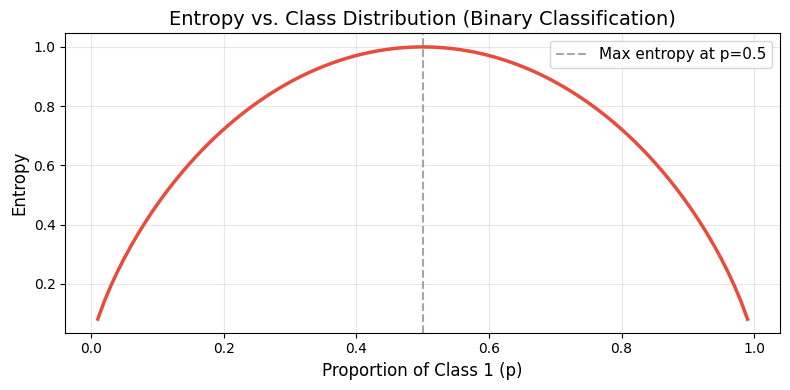

Entropy when all samples are class 0:  -0.0
Entropy when evenly split:             1.0
Entropy when mostly one class:         0.7219280948873623


In [3]:
# --- Let's visualize entropy ---

# Example: Binary classification (2 classes)
# Vary the proportion of class 1 from 0.01 to 0.99
p_values = np.linspace(0.01, 0.99, 100)
entropy_values = [-p * np.log2(p) - (1 - p) * np.log2(1 - p) for p in p_values]

plt.figure(figsize=(8, 4))
plt.plot(p_values, entropy_values, color='#e74c3c', linewidth=2.5)
plt.xlabel('Proportion of Class 1 (p)', fontsize=12)
plt.ylabel('Entropy', fontsize=12)
plt.title('Entropy vs. Class Distribution (Binary Classification)', fontsize=14)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Max entropy at p=0.5')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Entropy when all samples are class 0: ", entropy(np.array([0, 0, 0, 0, 0])))
print("Entropy when evenly split:            ", entropy(np.array([0, 0, 0, 1, 1, 1])))
print("Entropy when mostly one class:        ", entropy(np.array([0, 0, 0, 0, 1])))

---
## Step 2: Information Gain

**Information Gain** tells us how much a split *reduces* entropy.

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)$$

In simpler terms:
$$\text{Information Gain} = \text{Entropy(parent)} - \text{Weighted Average of Entropy(children)}$$

### How we split (for continuous features):
For a given feature and threshold `t`:
- **Left child**: all samples where `feature_value <= t`
- **Right child**: all samples where `feature_value > t`

We pick the split that gives the **highest information gain**.

In [4]:
def information_gain(y, y_left, y_right):
    """
    Calculate information gain from a split.
    
    Parameters:
        y       : labels of the parent node
        y_left  : labels of the left child
        y_right : labels of the right child
    
    Returns:
        float: Information gain
    """
    # Parent entropy
    parent_entropy = entropy(y)
    
    # Weighted average entropy of children
    n = len(y)
    n_left, n_right = len(y_left), len(y_right)
    
    if n_left == 0 or n_right == 0:
        return 0  # No actual split happened
    
    child_entropy = (n_left / n) * entropy(y_left) + (n_right / n) * entropy(y_right)
    
    # Information Gain = Parent Entropy - Child Entropy
    return parent_entropy - child_entropy

In [5]:
# --- Example: Visualize a good vs bad split ---

parent = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # 50-50 mix

# Good split: separates classes well
left_good  = np.array([0, 0, 0, 0])  # all class 0
right_good = np.array([1, 1, 1, 1])  # all class 1

# Bad split: doesn't separate classes
left_bad  = np.array([0, 0, 1, 1])  # mixed
right_bad = np.array([0, 0, 1, 1])  # mixed

ig_good = information_gain(parent, left_good, right_good)
ig_bad  = information_gain(parent, left_bad, right_bad)

print(f"Good split → Information Gain = {ig_good:.4f}  ✅ (Perfect separation)")
print(f"Bad split  → Information Gain = {ig_bad:.4f}   ❌ (No improvement)")

Good split → Information Gain = 1.0000  ✅ (Perfect separation)
Bad split  → Information Gain = 0.0000   ❌ (No improvement)


---
## Step 3: Finding the Best Split

For each node, we need to find the **best feature** and **best threshold** to split on.

Algorithm:
1. For each feature:
   - Sort the unique values
   - Try every possible threshold (midpoints between consecutive values)
   - Calculate information gain for each threshold
2. Pick the (feature, threshold) with the highest information gain

In [6]:
def best_split(X, y):
    """
    Find the best feature and threshold to split the data.
    
    Parameters:
        X (np.array): Feature matrix (n_samples, n_features)
        y (np.array): Label array (n_samples,)
        
    Returns:
        dict: {'feature_index', 'threshold', 'info_gain'} or None if no valid split
    """
    n_samples, n_features = X.shape
    
    if n_samples <= 1:
        return None
    
    best_gain = -1
    best_result = None
    
    for feature_idx in range(n_features):
        # Get the values for this feature
        feature_values = X[:, feature_idx]
        
        # Try thresholds at midpoints between sorted unique values
        sorted_unique = np.unique(feature_values)
        thresholds = (sorted_unique[:-1] + sorted_unique[1:]) / 2
        
        for threshold in thresholds:
            # Split the data
            left_mask = feature_values <= threshold
            right_mask = ~left_mask
            
            y_left = y[left_mask]
            y_right = y[right_mask]
            
            # Skip if split doesn't actually divide data
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            
            # Calculate information gain
            gain = information_gain(y, y_left, y_right)
            
            if gain > best_gain:
                best_gain = gain
                best_result = {
                    'feature_index': feature_idx,
                    'threshold': threshold,
                    'info_gain': gain
                }
    
    return best_result

---
## Step 4: Building the Decision Tree

Now we put it all together. The tree is built **recursively**:

```
function build_tree(X, y, depth):
    if stopping_condition_met:
        return LeafNode(most_common_class)
    
    find best_split(X, y)
    split data into left and right
    
    left_subtree  = build_tree(X_left, y_left, depth + 1)
    right_subtree = build_tree(X_right, y_right, depth + 1)
    
    return InternalNode(feature, threshold, left_subtree, right_subtree)
```

### Stopping Conditions (to prevent overfitting):
1. **Max depth** reached
2. **Min samples** — not enough samples to split
3. **Pure node** — all samples belong to the same class
4. **No information gain** — no split improves purity

In [7]:
class Node:
    """
    Represents a single node in the decision tree.
    
    - Internal nodes store: feature_index, threshold, left child, right child
    - Leaf nodes store: predicted class value
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, 
                 info_gain=None, value=None):
        # For internal (decision) nodes
        self.feature_index = feature_index  # which feature to split on
        self.threshold = threshold          # threshold value for the split
        self.left = left                    # left subtree (feature <= threshold)
        self.right = right                  # right subtree (feature > threshold)
        self.info_gain = info_gain          # information gain of this split
        
        # For leaf nodes
        self.value = value                  # predicted class
    
    def is_leaf(self):
        return self.value is not None

In [8]:
class DecisionTreeClassifier:
    """
    Decision Tree Classifier built from scratch.
    
    Parameters:
        max_depth   : Maximum depth of the tree (default=10)
        min_samples : Minimum samples required to split a node (default=2)
    """
    
    def __init__(self, max_depth=10, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.root = None
        self.n_features = None
        self.feature_names = None
        self.class_names = None
    
    def fit(self, X, y, feature_names=None, class_names=None):
        """
        Build the decision tree from training data.
        
        Parameters:
            X : np.array of shape (n_samples, n_features)
            y : np.array of shape (n_samples,)
            feature_names : list of feature name strings (optional)
            class_names   : list of class name strings (optional)
        """
        self.n_features = X.shape[1]
        self.feature_names = feature_names or [f'Feature {i}' for i in range(self.n_features)]
        self.class_names = class_names
        self.root = self._build_tree(X, y, depth=0)
        return self
    
    def _build_tree(self, X, y, depth):
        """
        Recursively build the decision tree.
        """
        n_samples = len(y)
        n_classes = len(np.unique(y))
        
        # ---- STOPPING CONDITIONS ----
        # 1. Max depth reached
        # 2. Not enough samples to split
        # 3. Node is already pure (only one class)
        if depth >= self.max_depth or n_samples < self.min_samples or n_classes == 1:
            # Return a leaf node with the most common class
            leaf_value = self._most_common_class(y)
            return Node(value=leaf_value)
        
        # ---- FIND THE BEST SPLIT ----
        split = best_split(X, y)
        
        # 4. No valid split found (no information gain)
        if split is None or split['info_gain'] <= 0:
            leaf_value = self._most_common_class(y)
            return Node(value=leaf_value)
        
        # ---- SPLIT THE DATA ----
        feature_idx = split['feature_index']
        threshold = split['threshold']
        
        left_mask = X[:, feature_idx] <= threshold
        right_mask = ~left_mask
        
        # ---- RECURSIVELY BUILD SUBTREES ----
        left_subtree  = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return Node(
            feature_index=feature_idx,
            threshold=threshold,
            left=left_subtree,
            right=right_subtree,
            info_gain=split['info_gain']
        )
    
    def _most_common_class(self, y):
        """Return the most common class label."""
        counter = Counter(y)
        return counter.most_common(1)[0][0]
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
            X : np.array of shape (n_samples, n_features)
        
        Returns:
            np.array of predicted labels
        """
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        """
        Traverse the tree to make a prediction for a single sample.
        
        At each internal node:
            - If feature value <= threshold → go LEFT
            - If feature value >  threshold → go RIGHT
        """
        # If we've reached a leaf, return its value
        if node.is_leaf():
            return node.value
        
        # Otherwise, decide which way to go
        if x[node.feature_index] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)
    
    def print_tree(self, node=None, depth=0, prefix="ROOT"):
        """
        Print a text representation of the tree.
        """
        if node is None:
            node = self.root
        
        indent = "    " * depth
        
        if node.is_leaf():
            class_label = self.class_names[node.value] if self.class_names else node.value
            print(f"{indent}{prefix} → 🍃 Predict: {class_label}")
        else:
            feature_name = self.feature_names[node.feature_index]
            print(f"{indent}{prefix} 🔀 [{feature_name} <= {node.threshold:.2f}?]  (IG={node.info_gain:.4f})")
            self.print_tree(node.left,  depth + 1, prefix="├── Yes")
            self.print_tree(node.right, depth + 1, prefix="└── No ")

---
## Step 5: Train & Test on the Iris Dataset 🌸

The **Iris dataset** is a classic ML dataset with:
- 150 samples of iris flowers
- 4 features: sepal length, sepal width, petal length, petal width
- 3 classes: Setosa, Versicolor, Virginica

In [ ]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print(f"Dataset shape: {X.shape}")
print(f"Features:      {iris.feature_names}")
print(f"Classes:       {list(iris.target_names)}")
print(f"Class distribution: {dict(Counter(y))}")

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

In [ ]:
# Build our Decision Tree!
tree = DecisionTreeClassifier(max_depth=5, min_samples=2)
tree.fit(
    X_train, y_train,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names)
)

print("✅ Tree built successfully!\n")
print("=" * 70)
print("DECISION TREE STRUCTURE")
print("=" * 70)
tree.print_tree()

In [ ]:
# Make predictions
y_pred = tree.predict(X_test)

# Calculate accuracy
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"\n🎯 Test Accuracy: {accuracy * 100:.2f}%")
print(f"   Correct: {np.sum(y_pred == y_test)} / {len(y_test)}")

# Show predictions vs actual for first 10 test samples
print("\n--- Sample Predictions ---")
print(f"{'Actual':<15} {'Predicted':<15} {'Correct?'}")
print("-" * 40)
for i in range(min(10, len(y_test))):
    actual = iris.target_names[y_test[i]]
    predicted = iris.target_names[y_pred[i]]
    correct = "✅" if y_test[i] == y_pred[i] else "❌"
    print(f"{actual:<15} {predicted:<15} {correct}")

---
## Step 6: Visualize the Tree 🎨

Let's create a visual representation of our tree using matplotlib.

In [ ]:
def get_tree_depth(node):
    """Get the maximum depth of the tree."""
    if node.is_leaf():
        return 0
    return 1 + max(get_tree_depth(node.left), get_tree_depth(node.right))

def count_leaves(node):
    """Count the number of leaf nodes."""
    if node.is_leaf():
        return 1
    return count_leaves(node.left) + count_leaves(node.right)


def plot_tree(tree_clf, figsize=(20, 10)):
    """Visualize the decision tree using matplotlib."""
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Decision Tree Visualization', fontsize=18, fontweight='bold', pad=20)
    
    depth = get_tree_depth(tree_clf.root)
    
    colors = {
        'internal': '#3498db',
        'leaf': ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
    }
    
    def draw_node(node, x, y, x_range, current_depth):
        if node.is_leaf():
            class_label = tree_clf.class_names[node.value] if tree_clf.class_names else str(node.value)
            color = colors['leaf'][node.value % len(colors['leaf'])]
            box = dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.8, edgecolor='white', linewidth=2)
            ax.text(x, y, f"{class_label}", ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white', bbox=box)
        else:
            feature_name = tree_clf.feature_names[node.feature_index]
            short_name = feature_name.replace(' (cm)', '').replace('sepal ', 'S.').replace('petal ', 'P.')
            label = f"{short_name}\n≤ {node.threshold:.2f}"
            box = dict(boxstyle='round,pad=0.4', facecolor=colors['internal'], alpha=0.85, edgecolor='white', linewidth=2)
            ax.text(x, y, label, ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white', bbox=box)
            
            # Calculate child positions
            dy = 0.8 / (depth + 1)
            dx = x_range / 2
            
            left_x = x - dx / 2
            right_x = x + dx / 2
            child_y = y - dy
            
            # Draw edges
            ax.plot([x, left_x], [y - 0.02, child_y + 0.02], 'gray', linewidth=1.5, alpha=0.6)
            ax.plot([x, right_x], [y - 0.02, child_y + 0.02], 'gray', linewidth=1.5, alpha=0.6)
            
            # Add Yes/No labels
            if current_depth == 0:
                ax.text((x + left_x) / 2 - 0.01, (y + child_y) / 2, 'Yes', fontsize=7, color='green', fontweight='bold')
                ax.text((x + right_x) / 2 + 0.01, (y + child_y) / 2, 'No', fontsize=7, color='red', fontweight='bold')
            
            # Recurse
            draw_node(node.left, left_x, child_y, dx, current_depth + 1)
            draw_node(node.right, right_x, child_y, dx, current_depth + 1)
    
    draw_node(tree_clf.root, 0.5, 0.92, 0.9, 0)
    plt.tight_layout()
    plt.show()


plot_tree(tree)

---
## Step 7: Compare with scikit-learn 🔬

Let's verify that our from-scratch implementation performs comparably to scikit-learn's optimized version.

In [ ]:
from sklearn.tree import DecisionTreeClassifier as SklearnDT

# Train sklearn's decision tree
sklearn_tree = SklearnDT(max_depth=5, criterion='entropy', random_state=42)
sklearn_tree.fit(X_train, y_train)
sklearn_pred = sklearn_tree.predict(X_test)
sklearn_acc = np.sum(sklearn_pred == y_test) / len(y_test)

# Our tree
our_acc = np.sum(y_pred == y_test) / len(y_test)

print("=" * 50)
print("       ACCURACY COMPARISON")
print("=" * 50)
print(f"  Our Decision Tree:     {our_acc * 100:.2f}%")
print(f"  Sklearn Decision Tree: {sklearn_acc * 100:.2f}%")
print("=" * 50)

if our_acc >= sklearn_acc:
    print("\n🎉 Our tree matches or beats sklearn!")
else:
    print(f"\n📊 Sklearn is ahead by {(sklearn_acc - our_acc) * 100:.2f}%")
    print("   (Sklearn uses optimizations like pre-sorting and pruning)")

---
## Step 8: Experiment — Effect of Max Depth 📊

Let's see how `max_depth` affects accuracy. Too shallow = underfitting. Too deep = overfitting.

In [ ]:
depths = range(1, 11)
train_accs = []
test_accs = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, min_samples=2)
    t.fit(X_train, y_train)
    
    train_pred = t.predict(X_train)
    test_pred  = t.predict(X_test)
    
    train_accs.append(np.mean(train_pred == y_train))
    test_accs.append(np.mean(test_pred == y_test))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, 'o-', color='#3498db', linewidth=2, markersize=8, label='Train Accuracy')
plt.plot(depths, test_accs, 's-', color='#e74c3c', linewidth=2, markersize=8, label='Test Accuracy')
plt.xlabel('Max Depth', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Effect of Max Depth on Decision Tree Performance', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.xticks(depths)
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.02)
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(test_accs)]
print(f"\n🏆 Best test accuracy: {max(test_accs)*100:.2f}% at max_depth = {best_depth}")

---
## Step 9: Decision Boundary Visualization 🗺️

Let's visualize how our tree partitions the feature space using 2 features.

In [ ]:
# Use only petal length (feature 2) and petal width (feature 3) for 2D visualization
X_2d = X[:, 2:4]  # petal length & petal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

# Train a tree on 2D data
tree_2d = DecisionTreeClassifier(max_depth=5, min_samples=2)
tree_2d.fit(X_train_2d, y_train_2d, feature_names=['petal length', 'petal width'])

# Create mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict on mesh
Z = tree_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
cmap_bg = plt.cm.RdYlGn
cmap_pts = ['#e74c3c', '#f39c12', '#2ecc71']

ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg, levels=2)
ax.contour(xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.5)

for idx, (name, color) in enumerate(zip(iris.target_names, cmap_pts)):
    mask = y == idx
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name,
               edgecolors='white', s=60, linewidth=0.8, alpha=0.9)

ax.set_xlabel('Petal Length (cm)', fontsize=13)
ax.set_ylabel('Petal Width (cm)', fontsize=13)
ax.set_title('Decision Boundary (Our Tree from Scratch)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, title='Species', title_fontsize=12)
plt.tight_layout()
plt.show()

acc_2d = np.mean(tree_2d.predict(X_test_2d) == y_test_2d)
print(f"\n2D Tree Accuracy: {acc_2d * 100:.2f}%")

---
## 📝 Summary: What We Learned

### Key Concepts

| Concept | Description |
|---------|-------------|
| **Entropy** | Measures impurity/uncertainty in a set of labels. Lower = purer. |
| **Information Gain** | Reduction in entropy after a split. We pick the split with highest IG. |
| **Recursive Splitting** | The tree is built top-down by repeatedly finding the best split. |
| **Stopping Conditions** | Max depth, min samples, pure node, or no gain — prevents overfitting. |
| **Prediction** | Traverse from root to leaf following the learned split rules. |

### Pros & Cons of Decision Trees

**✅ Pros:**
- Easy to understand and interpret (white-box model)
- No feature scaling needed
- Handles both numerical and categorical features
- Fast prediction (just a few if-else checks)

**❌ Cons:**
- Prone to overfitting (especially deep trees)
- Sensitive to small changes in data
- Creates axis-aligned boundaries only (can't capture diagonal relationships)
- Greedy algorithm — doesn't guarantee globally optimal tree

### Next Steps
- 🌲 **Random Forest**: Build many trees on random subsets → reduces overfitting
- 🚀 **Gradient Boosting (XGBoost/LightGBM)**: Build trees sequentially, each correcting errors
- 🔀 **Gini Impurity**: Alternative to entropy (used by sklearn by default)
- ✂️ **Pruning**: Remove branches that don't improve generalization